In [1]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression


In [2]:
df=pd.read_csv('dataset.csv')
df.head()

,Country Name,Country Code,Series Name,Series Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,6.20000000000001,7.2,8.2,9.5,10.9,12.2,13.85,15.3,16.7,18.4,20,21.8,23,24.8,26.1,27.4
1,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,1.61359095573425,4.07457399368286,9.40915775299072,14.7385063171387,20.0649681091309,25.3908939361572,30.7186908721924,36.0510101318359,42.4000015258789,46.7400512695313,42.7000007629395,43.2220191955566,69.0999984741211,68.2906494140625,89.5,71.5
2,Afghanistan,AFG,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,..,..,..,..,3.24060392379761,11.1138515472412,15.7653656005859,22.0606784820557,27.9542503356934,34.7457847595215,30.2187995910645,29.5728797912598,60.8491554260254,60.5661354064941,86.5005111694336,64.573356628418
3,Afghanistan,AFG,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS,72.1334686279297,73.5990371704102,75.0632781982422,76.5331344604492,78.0155563354492,74,81.0437698364258,82.5908203125,89.9000015258789,85.7244720458984,82.8000030517578,86.5677795410156,95,92.2590484619141,98.6999969482422,92.5
4,Afghanistan,AFG,Adjusted savings: natural resources depletion ...,NY.ADJ.DRES.GN.ZS,..,..,..,..,..,..,..,..,..,0.265019028375943,0.354491193186429,0.397696520878019,0.386703580037567,0.289482199333597,0.288231474992077,0.29524233685244


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26912 entries, 0 to 26911
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country Name  26909 non-null  object
 1   Country Code  26908 non-null  object
 2   Series Name   26908 non-null  object
 3   Series Code   26908 non-null  object
 4   2000          26908 non-null  object
 5   2001          26908 non-null  object
 6   2002          26908 non-null  object
 7   2003          26908 non-null  object
 8   2004          26908 non-null  object
 9   2005          26908 non-null  object
 10  2006          26908 non-null  object
 11  2007          26908 non-null  object
 12  2008          26908 non-null  object
 13  2009          26908 non-null  object
 14  2010          26908 non-null  object
 15  2011          26908 non-null  object
 16  2012          26908 non-null  object
 17  2013          26908 non-null  object
 18  2014          26908 non-null  object
 19  2015

<div class="alert alert-block alert-info">
    <b> changing dataset from object to float64 </b>
</div>

In [4]:
col=df.columns
for i in range(4,20):
    l=col[i]
    df[l]=pd.to_numeric(df[l],errors='coerce')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26912 entries, 0 to 26911
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  26909 non-null  object 
 1   Country Code  26908 non-null  object 
 2   Series Name   26908 non-null  object 
 3   Series Code   26908 non-null  object 
 4   2000          16631 non-null  float64
 5   2001          15566 non-null  float64
 6   2002          15730 non-null  float64
 7   2003          15635 non-null  float64
 8   2004          16066 non-null  float64
 9   2005          16771 non-null  float64
 10  2006          16310 non-null  float64
 11  2007          16187 non-null  float64
 12  2008          16348 non-null  float64
 13  2009          15808 non-null  float64
 14  2010          17131 non-null  float64
 15  2011          16346 non-null  float64
 16  2012          16450 non-null  float64
 17  2013          16407 non-null  float64
 18  2014          16790 non-nu

In [6]:
df1=df.iloc[:,4:20]
# finding row average of all the data of our given dataset
df1['row_average']=df1.mean(axis=1)
df1

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,row_average
0,6.200000,7.200000,8.200000,9.500000,10.900000,12.200000,13.850000,15.300000,16.700000,18.400000,20.000000,21.800000,23.000000,24.800000,26.100000,27.400000,16.346875
1,1.613591,4.074574,9.409158,14.738506,20.064968,25.390894,30.718691,36.051010,42.400002,46.740051,42.700001,43.222019,69.099998,68.290649,89.500000,71.500000,38.469632
2,NaN,NaN,NaN,NaN,3.240604,11.113852,15.765366,22.060678,27.954250,34.745785,30.218800,29.572880,60.849155,60.566135,86.500511,64.573357,37.263448
3,72.133469,73.599037,75.063278,76.533134,78.015556,74.000000,81.043770,82.590820,89.900002,85.724472,82.800003,86.567780,95.000000,92.259048,98.699997,92.500000,83.526898
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.265019,0.354491,0.397697,0.386704,0.289482,0.288231,0.295242,0.325267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26907,70.000000,70.000000,75.625000,75.625000,75.625000,75.625000,84.375000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,81.796875
26908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Filling NaN values with row average

In [7]:
col2=df1.columns
for i in col2:   
    df1.fillna({i:df1["row_average"]},inplace=True)
df1

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,row_average
0,6.200000,7.200000,8.200000,9.500000,10.900000,12.200000,13.850000,15.300000,16.700000,18.400000,20.000000,21.800000,23.000000,24.800000,26.100000,27.400000,16.346875
1,1.613591,4.074574,9.409158,14.738506,20.064968,25.390894,30.718691,36.051010,42.400002,46.740051,42.700001,43.222019,69.099998,68.290649,89.500000,71.500000,38.469632
2,37.263448,37.263448,37.263448,37.263448,3.240604,11.113852,15.765366,22.060678,27.954250,34.745785,30.218800,29.572880,60.849155,60.566135,86.500511,64.573357,37.263448
3,72.133469,73.599037,75.063278,76.533134,78.015556,74.000000,81.043770,82.590820,89.900002,85.724472,82.800003,86.567780,95.000000,92.259048,98.699997,92.500000,83.526898
4,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.265019,0.354491,0.397697,0.386704,0.289482,0.288231,0.295242,0.325267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26907,70.000000,70.000000,75.625000,75.625000,75.625000,75.625000,84.375000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,86.875000,81.796875
26908,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_clean=df1.dropna() #dropping NaN values
df_clean

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,row_average
0,6.200000,7.200000,8.200000,9.500000,10.900000,12.200000,13.850000,15.300000,16.700000,18.400000,20.000000,21.800000,23.000000,24.800000,26.100000,27.400000,16.346875
1,1.613591,4.074574,9.409158,14.738506,20.064968,25.390894,30.718691,36.051010,42.400002,46.740051,42.700001,43.222019,69.099998,68.290649,89.500000,71.500000,38.469632
2,37.263448,37.263448,37.263448,37.263448,3.240604,11.113852,15.765366,22.060678,27.954250,34.745785,30.218800,29.572880,60.849155,60.566135,86.500511,64.573357,37.263448
3,72.133469,73.599037,75.063278,76.533134,78.015556,74.000000,81.043770,82.590820,89.900002,85.724472,82.800003,86.567780,95.000000,92.259048,98.699997,92.500000,83.526898
4,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.325267,0.265019,0.354491,0.397697,0.386704,0.289482,0.288231,0.295242,0.325267
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26903,5.688000,5.355000,5.062000,4.750000,4.390000,4.538000,4.681000,4.829000,5.014000,5.083000,5.209000,5.370000,5.153000,4.982000,4.770000,4.778000,4.978250
26904,12.720532,12.720532,12.720532,12.720532,12.720532,12.720532,15.500000,12.720532,12.720532,12.720532,12.720532,14.600000,12.720532,12.720532,10.382129,10.400000,12.720532
26905,33.758000,34.170000,34.585000,34.479000,34.294000,34.110000,33.926000,33.743000,33.560000,33.378000,33.196000,33.015000,32.834000,32.654000,32.504000,32.385000,33.536938
26906,0.000000,0.000000,0.000000,19.000000,20.000000,81.000000,67.000000,83.000000,0.000000,77.000000,49.000000,47.000000,61.000000,34.000000,32.000000,45.000000,38.437500


<Axes: >

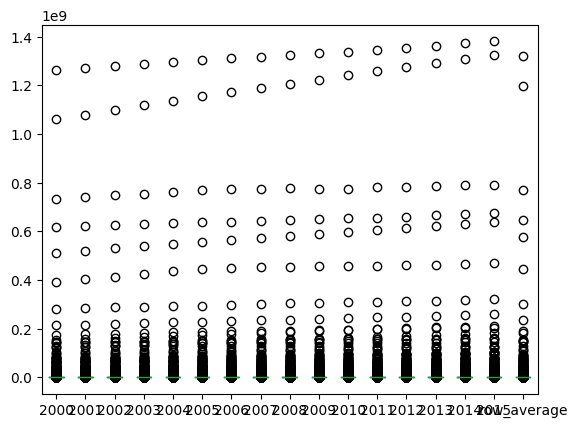

In [9]:
df_clean.plot.box() #plotting the bo to find outliers

# Cleaning Outliers

In [10]:

df_clean2 = df_clean.copy() 

for i in col2:
    Q1=df_clean2[i].quantile(0.25)
    Q3=df_clean2[i].quantile(0.75)
    IQR=Q3 - Q1

    df_clean2=df_clean2[(df_clean2[i] >= (Q1 - 1.5 * IQR)) & (df_clean2[i] <= (Q3 + 1.5 * IQR))]

<Axes: >

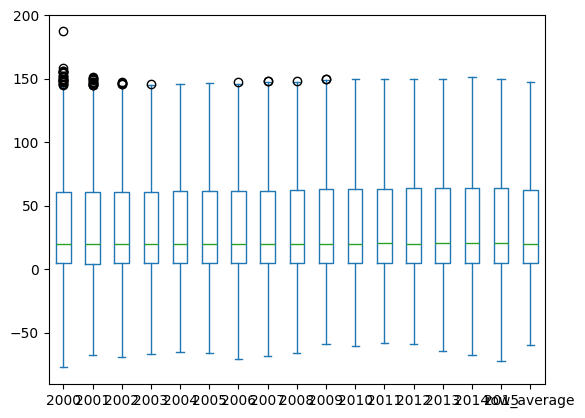

In [11]:
df_clean2.plot.box()

In [12]:
df_clean2.insert(0,"country",df["Country Name"])
df_clean2.insert(1,"indicators",df["Series Name"])

# Changing the format of dataset

This is done to make sure countries are in same row to make clusters

In [13]:
df_pivot=df_clean2.pivot(index='country', columns='indicators', values=[str(year) for year in range(2000, 2016)])
df_pivot.columns=['_'.join(col).strip() for col in df_pivot.columns] #so to make years and indicators together
df_pivot.reset_index(inplace=True)
df_pivot

,country,2000_Access to clean fuels and technologies for cooking (% of population),2000_Access to electricity (% of population),"2000_Access to electricity, rural (% of rural population)","2000_Access to electricity, urban (% of urban population)",2000_Adjusted savings: natural resources depletion (% of GNI),2000_Adjusted savings: net forest depletion (% of GNI),2000_Adolescents out of school (% of lower secondary school age),2000_Age dependency ratio (% of working-age population),2000_Agricultural land (% of land area),...,2015_Time required to get electricity (days),"2015_Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)","2015_Trained teachers in lower secondary education, male (% of male teachers)","2015_Trained teachers in secondary education, male (% of male teachers)","2015_Unemployment, female (% of female labor force) (modeled ILO estimate)","2015_Unemployment, total (% of total labor force) (modeled ILO estimate)",2015_Unmet need for contraception (% of married women ages 15-49),2015_Urban population (% of total population),2015_Vitamin A supplementation coverage rate (% of children ages 6-59 months),2015_Women Business and the Law Index Score (scale 1-100)
0,Afghanistan,6.2,1.613591,37.263448,72.133469,0.325267,0.235844,NaN,108.346635,57.882955,...,NaN,0.210,NaN,NaN,14.094000,11.127000,24.500000,24.803,98.000000,28.750
1,Albania,38.2,100.000000,100.000000,100.000000,0.415801,0.122940,7.121670,59.657295,41.751825,...,NaN,6.740,NaN,NaN,17.114000,17.190001,12.900000,57.434,NaN,85.625
2,Algeria,97.1,98.973099,98.268158,99.444649,16.876492,0.000000,NaN,61.500880,16.803261,...,NaN,0.930,NaN,NaN,16.566999,11.210000,9.400000,70.848,NaN,55.000
3,American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.473619,29.850000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.238,NaN,NaN
4,Andorra,100.0,100.000000,100.000000,100.000000,NaN,NaN,NaN,38.879667,48.936170,...,NaN,11.010,100.000000,100.000000,NaN,NaN,NaN,88.345,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),NaN,100.000000,100.000000,100.000000,NaN,NaN,NaN,53.283199,20.000000,...,NaN,NaN,NaN,NaN,13.897000,12.617000,NaN,95.350,NaN,NaN
213,West Bank and Gaza,NaN,99.699997,99.186508,99.900002,NaN,NaN,17.023149,99.655302,82.890365,...,64.0,NaN,100.000000,100.000000,34.298000,23.000000,13.238519,75.368,NaN,26.250
214,"Yemen, Rep.",55.7,49.187256,33.932995,92.006851,29.846964,0.024413,35.701361,108.441683,44.830199,...,72.5,0.055,NaN,NaN,26.426001,13.770000,26.150000,34.777,8.000000,26.875
215,Zambia,13.8,16.700001,2.074172,44.099998,9.147099,8.835550,NaN,102.618954,30.264061,...,117.0,6.890,89.719627,91.744049,10.772000,10.125000,25.066667,41.907,76.916667,63.125


In [14]:
# filling NaN values using K Nearest Neighbours
imputer=KNNImputer(n_neighbors=5)
df_pivot.iloc[:, 1:]=imputer.fit_transform(df_pivot.iloc[:, 1:])

In [15]:
print(df_pivot.isnull().sum().sum())  #finding no of NaN values
df_pivot


0


,country,2000_Access to clean fuels and technologies for cooking (% of population),2000_Access to electricity (% of population),"2000_Access to electricity, rural (% of rural population)","2000_Access to electricity, urban (% of urban population)",2000_Adjusted savings: natural resources depletion (% of GNI),2000_Adjusted savings: net forest depletion (% of GNI),2000_Adolescents out of school (% of lower secondary school age),2000_Age dependency ratio (% of working-age population),2000_Agricultural land (% of land area),...,2015_Time required to get electricity (days),"2015_Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)","2015_Trained teachers in lower secondary education, male (% of male teachers)","2015_Trained teachers in secondary education, male (% of male teachers)","2015_Unemployment, female (% of female labor force) (modeled ILO estimate)","2015_Unemployment, total (% of total labor force) (modeled ILO estimate)",2015_Unmet need for contraception (% of married women ages 15-49),2015_Urban population (% of total population),2015_Vitamin A supplementation coverage rate (% of children ages 6-59 months),2015_Women Business and the Law Index Score (scale 1-100)
0,Afghanistan,6.20,1.613591,37.263448,72.133469,0.325267,0.235844,51.399895,108.346635,57.882955,...,82.000,0.210,76.583329,77.371908,14.094000,11.127000,24.500000,24.803,98.000000,28.750
1,Albania,38.20,100.000000,100.000000,100.000000,0.415801,0.122940,7.121670,59.657295,41.751825,...,75.868,6.740,84.183767,86.480887,17.114000,17.190001,12.900000,57.434,49.523077,85.625
2,Algeria,97.10,98.973099,98.268158,99.444649,16.876492,0.000000,9.131270,61.500880,16.803261,...,69.200,0.930,100.000000,83.498030,16.566999,11.210000,9.400000,70.848,57.956410,55.000
3,American Samoa,96.20,99.921600,99.920500,99.984000,0.145957,0.006982,6.947335,76.473619,29.850000,...,55.580,8.948,69.208054,81.969407,9.695400,9.879400,8.606530,87.238,44.616410,79.125
4,Andorra,100.00,100.000000,100.000000,100.000000,1.451276,0.043426,3.538752,38.879667,48.936170,...,50.200,11.010,100.000000,100.000000,10.843200,10.208000,6.267590,88.345,47.216410,89.250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),98.92,100.000000,100.000000,100.000000,6.271150,0.015311,5.874522,53.283199,20.000000,...,43.800,7.470,85.225619,87.701932,13.897000,12.617000,7.873196,95.350,39.216410,79.375
213,West Bank and Gaza,78.72,99.699997,99.186508,99.900002,5.383625,0.019825,17.023149,99.655302,82.890365,...,64.000,1.460,100.000000,100.000000,34.298000,23.000000,13.238519,75.368,58.556410,26.250
214,"Yemen, Rep.",55.70,49.187256,33.932995,92.006851,29.846964,0.024413,35.701361,108.441683,44.830199,...,72.500,0.055,82.299375,82.684160,26.426001,13.770000,26.150000,34.777,8.000000,26.875
215,Zambia,13.80,16.700001,2.074172,44.099998,9.147099,8.835550,35.925475,102.618954,30.264061,...,117.000,6.890,89.719627,91.744049,10.772000,10.125000,25.066667,41.907,76.916667,63.125


# Using PCA 
- Standardize the data  
-  it is so that computation is easy 
- we are choosing components explaining 90-95% variance


In [16]:
scaler=StandardScaler()
df_scaled=scaler.fit_transform(df_pivot.iloc[:, 1:])

pca=PCA(n_components=0.95)  # Keep 95% variance
df_pca=pca.fit_transform(df_scaled)


# Using Explained Variance
- Plotting the graph of explained variance to know how many components is required for a more than 95% variance

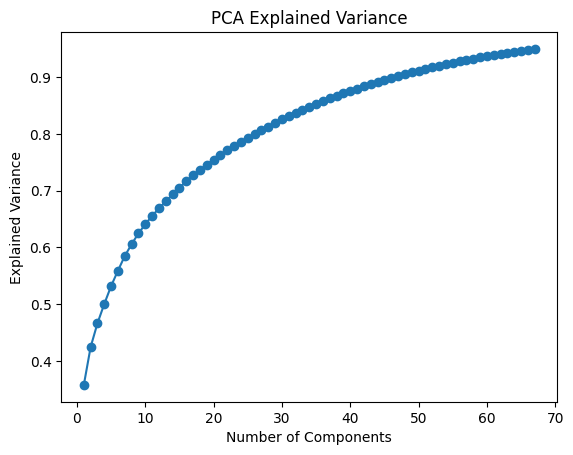

In [17]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(explained_variance) + 1),explained_variance,marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('PCA Explained Variance')
plt.show()


# Creating clusters 

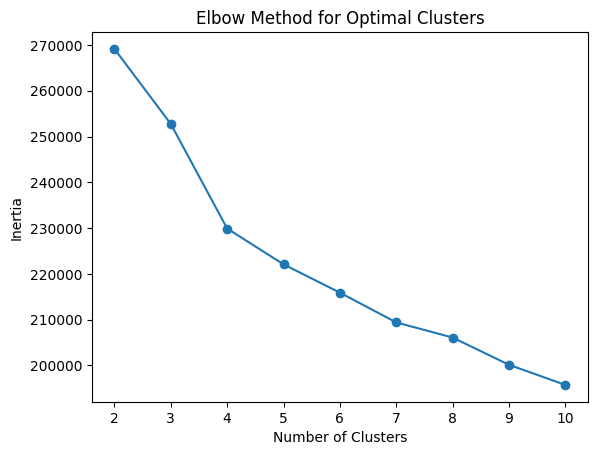

In [18]:
inertia=[]
for i in range(2,11): #trying different clusters size
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11),inertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

We can infer that optimal clusters from this graph is 4

In [19]:
kmeans=KMeans(n_clusters=4,random_state=42)
df_pivot['Cluster']=kmeans.fit_predict(df_pca)
df_pivot

,country,2000_Access to clean fuels and technologies for cooking (% of population),2000_Access to electricity (% of population),"2000_Access to electricity, rural (% of rural population)","2000_Access to electricity, urban (% of urban population)",2000_Adjusted savings: natural resources depletion (% of GNI),2000_Adjusted savings: net forest depletion (% of GNI),2000_Adolescents out of school (% of lower secondary school age),2000_Age dependency ratio (% of working-age population),2000_Agricultural land (% of land area),...,"2015_Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)","2015_Trained teachers in lower secondary education, male (% of male teachers)","2015_Trained teachers in secondary education, male (% of male teachers)","2015_Unemployment, female (% of female labor force) (modeled ILO estimate)","2015_Unemployment, total (% of total labor force) (modeled ILO estimate)",2015_Unmet need for contraception (% of married women ages 15-49),2015_Urban population (% of total population),2015_Vitamin A supplementation coverage rate (% of children ages 6-59 months),2015_Women Business and the Law Index Score (scale 1-100),Cluster
0,Afghanistan,6.20,1.613591,37.263448,72.133469,0.325267,0.235844,51.399895,108.346635,57.882955,...,0.210,76.583329,77.371908,14.094000,11.127000,24.500000,24.803,98.000000,28.750,0
1,Albania,38.20,100.000000,100.000000,100.000000,0.415801,0.122940,7.121670,59.657295,41.751825,...,6.740,84.183767,86.480887,17.114000,17.190001,12.900000,57.434,49.523077,85.625,3
2,Algeria,97.10,98.973099,98.268158,99.444649,16.876492,0.000000,9.131270,61.500880,16.803261,...,0.930,100.000000,83.498030,16.566999,11.210000,9.400000,70.848,57.956410,55.000,2
3,American Samoa,96.20,99.921600,99.920500,99.984000,0.145957,0.006982,6.947335,76.473619,29.850000,...,8.948,69.208054,81.969407,9.695400,9.879400,8.606530,87.238,44.616410,79.125,1
4,Andorra,100.00,100.000000,100.000000,100.000000,1.451276,0.043426,3.538752,38.879667,48.936170,...,11.010,100.000000,100.000000,10.843200,10.208000,6.267590,88.345,47.216410,89.250,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),98.92,100.000000,100.000000,100.000000,6.271150,0.015311,5.874522,53.283199,20.000000,...,7.470,85.225619,87.701932,13.897000,12.617000,7.873196,95.350,39.216410,79.375,1
213,West Bank and Gaza,78.72,99.699997,99.186508,99.900002,5.383625,0.019825,17.023149,99.655302,82.890365,...,1.460,100.000000,100.000000,34.298000,23.000000,13.238519,75.368,58.556410,26.250,2
214,"Yemen, Rep.",55.70,49.187256,33.932995,92.006851,29.846964,0.024413,35.701361,108.441683,44.830199,...,0.055,82.299375,82.684160,26.426001,13.770000,26.150000,34.777,8.000000,26.875,0
215,Zambia,13.80,16.700001,2.074172,44.099998,9.147099,8.835550,35.925475,102.618954,30.264061,...,6.890,89.719627,91.744049,10.772000,10.125000,25.066667,41.907,76.916667,63.125,0


# Visualizing the clusters


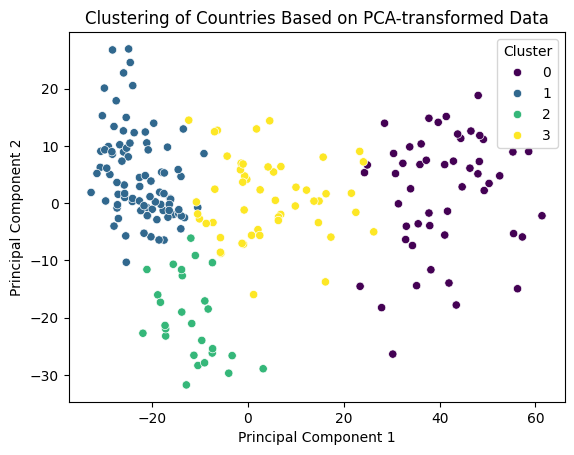

In [20]:
pca_2d=PCA(n_components=2)
df_pca_2d=pca_2d.fit_transform(df_scaled)

plt.Figure(figsize=(12,8))
sns.scatterplot(x=df_pca[:, 0],y=df_pca_2d[:, 1],hue=df_pivot['Cluster'],palette="viridis")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clustering of Countries Based on PCA-transformed Data")
plt.legend(title="Cluster")
plt.show()

# Extracting and Standardizing only 2005 and 2015 data

In [21]:
df_2005=df_pivot[['country'] + [col for col in df_pivot.columns if '2005' in col]]
df_2015=df_pivot[['country'] + [col for col in df_pivot.columns if '2015' in col]]

scaler=StandardScaler()
df_2005_scaled=scaler.fit_transform(df_2005.iloc[:, 1:])
df_2015_scaled=scaler.fit_transform(df_2015.iloc[:, 1:])


# Applying PCA on these datas

In [22]:
pca_2005=PCA(n_components=0.95) #choosing components having 0.95 variance
df_2005_pca=pca_2005.fit_transform(df_2005_scaled)

pca_2015=PCA(n_components=0.95)
df_2015_pca=pca_2015.fit_transform(df_2015_scaled)

# Creating cluster of these datas

In [23]:
kmeans_2005 =KMeans(n_clusters=4,random_state=42)
df_2005.loc[:,'Cluster_2005']=kmeans_2005.fit_predict(df_2005_pca)

# Cluster 2015 data
kmeans_2015 =KMeans(n_clusters=4,random_state=42)
df_2015.loc[:,'Cluster_2015']=kmeans_2015.fit_predict(df_2015_pca)

C:\Users\user\AppData\Local\Temp\ipykernel_12088\1903301753.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2005.loc[:,'Cluster_2005']=kmeans_2005.fit_predict(df_2005_pca)
C:\Users\user\AppData\Local\Temp\ipykernel_12088\1903301753.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2015.loc[:,'Cluster_2015']=kmeans_2015.fit_predict(df_2015_pca)


# Finding countries which changed their cluster form 2005 to 2015


In [24]:
df_clusters=df_2005[['country','Cluster_2005']].merge(df_2015[['country','Cluster_2015']],on='country',how='inner')

df_clusters['Changed']=df_clusters['Cluster_2005']!=df_clusters['Cluster_2015']


In [25]:
print(f"\nTotal countries that changed clusters:{df_clusters['Changed'].sum()}")
print(df_clusters.head(10))


Total countries that changed clusters:82
               country  Cluster_2005  Cluster_2015  Changed
0          Afghanistan             0             0    False
1              Albania             3             1     True
2              Algeria             2             3     True
3       American Samoa             1             1    False
4              Andorra             1             1    False
5               Angola             0             0    False
6  Antigua and Barbuda             1             1    False
7            Argentina             1             1    False
8              Armenia             1             1    False
9                Aruba             1             1    False


## A heatmap to visualize no of countries which changed their clusters

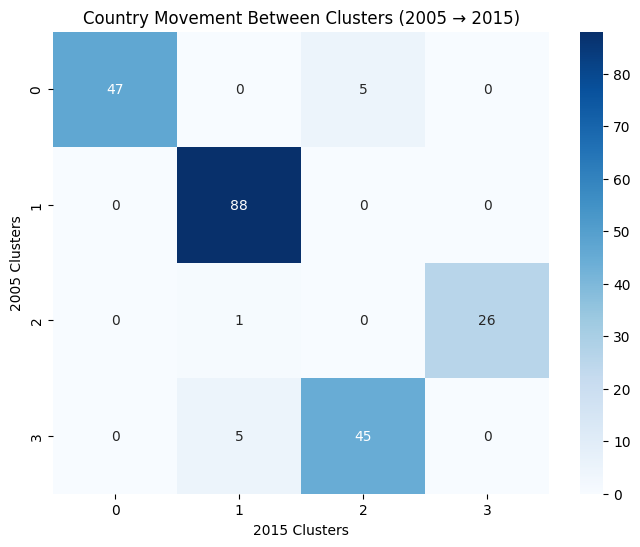

In [26]:
changed_matrix=pd.crosstab(df_clusters['Cluster_2005'],df_clusters['Cluster_2015'])

plt.figure(figsize=(8, 6))
sns.heatmap(changed_matrix,annot=True,cmap="Blues")
plt.xlabel("2015 Clusters")
plt.ylabel("2005 Clusters")
plt.title("Country Movement Between Clusters (2005 → 2015)")
plt.show()

# Finding the worst cluster and countries in it
 

In [27]:
df_2015_numeric=df_2015.drop(columns=["country", "Cluster_2015"]).apply(pd.to_numeric,errors="coerce")
cluster_means=df_2015_numeric.groupby(df_2015["Cluster_2015"]).mean()

# Identify the worst-performing cluster
worst_cluster=cluster_means.mean(axis=1).idxmin()
print(f"Worst-performing cluster: {worst_cluster}")

# List countries in this cluster
worst_cluster_countries=df_2015[df_2015["Cluster_2015"]==worst_cluster]["country"]
no_of_countries=worst_cluster_countries.shape
print("no of worst performing countries", no_of_countries)
print("Countries in worst cluster:\n", worst_cluster_countries.tolist())

Worst-performing cluster: 0
no of worst performing countries (47,)
Countries in worst cluster:
 ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Kenya', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Nepal', 'Niger', 'Nigeria', 'Pakistan', 'Papua New Guinea', 'Rwanda', 'Senegal', 'Sierra Leone', 'Somalia', 'South Sudan', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen, Rep.', 'Zambia']


# Finding key indicators responsible for it


In [28]:
worst_cluster_indicators=cluster_means.loc[0] - df_2015.drop(columns=["country", "Cluster_2015"]).mean()

# Sort indicators by lowest performance
worst_cluster_indicators=worst_cluster_indicators.sort_values()

# Display top 10 worst indicators
print("Top 10 Weakest Indicators in the Worst-Performing Cluster:\n")
print(worst_cluster_indicators.head(10))


Top 10 Weakest Indicators in the Worst-Performing Cluster:

2015_Access to clean fuels and technologies for cooking (% of population)                               -56.323904
2015_Access to electricity, rural (% of rural population)                                               -55.933655
2015_People using safely managed drinking water services (% of population)                              -45.450083
2015_Access to electricity (% of population)                                                            -43.487717
2015_People with basic handwashing facilities including soap and water, rural (% of rural population)   -42.924569
2015_People using safely managed drinking water services, rural (% of rural population)                 -42.267607
2015_School enrollment, secondary (% gross)                                                             -41.604908
2015_School enrollment, secondary, female (% net)                                                       -40.909277
2015_Literacy rate, 

C:\Users\user\AppData\Local\Temp\ipykernel_12088\497178535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=worst_cluster_indicators.index[:10], x=worst_cluster_indicators.values[:10], palette="Reds_r")


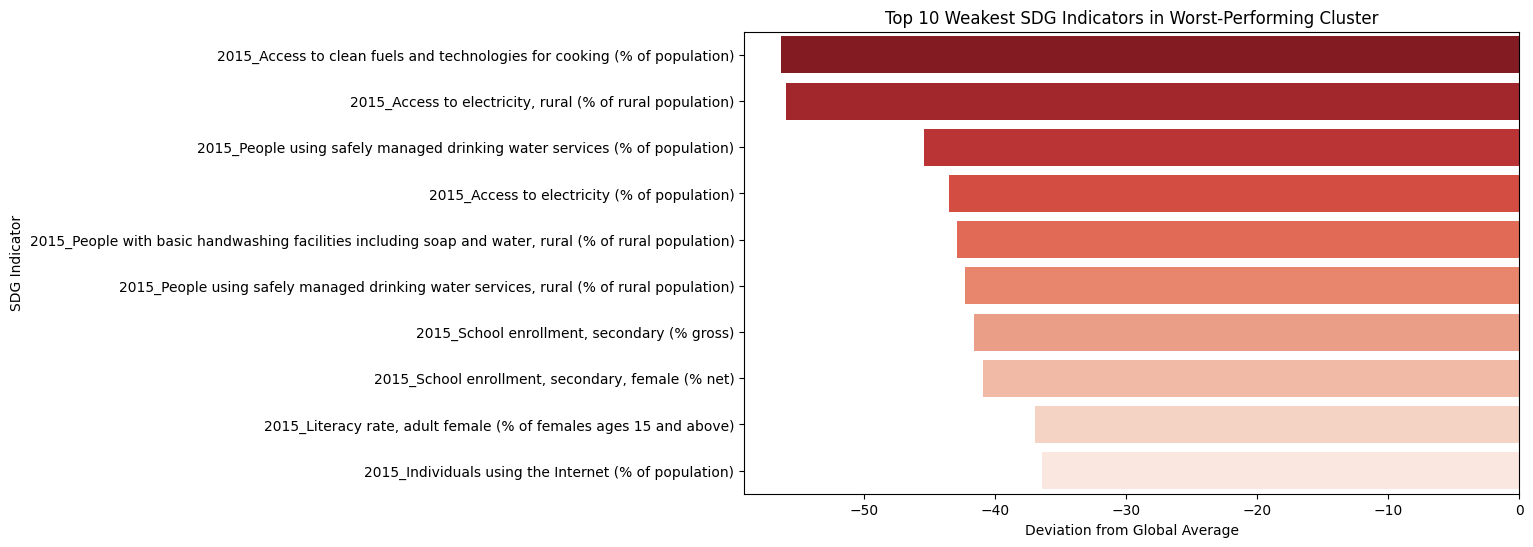

In [29]:
# Barplot of worst indicators
plt.figure(figsize=(10,6))
sns.barplot(y=worst_cluster_indicators.index[:10], x=worst_cluster_indicators.values[:10], palette="Reds_r")
plt.xlabel("Deviation from Global Average")
plt.ylabel("SDG Indicator")
plt.title("Top 10 Weakest SDG Indicators in Worst-Performing Cluster")
plt.show()


# Illustrating trends and disparities in worst-performing cluster

In [30]:
key_indicators = ["Access to clean fuels and technologies for cooking (% of population)","Access to electricity, rural (% of rural population)","People using safely managed drinking water services (% of population)"
                  "Access to electricity (% of population) ","People with basic handwashing facilities including soap and water, rural (% of rural population)","People using safely managed drinking water services, rural (% of rural population)","School enrollment, secondary (% gross)",
                  "School enrollment, secondary, female (% net)","Literacy rate, adult female (% of females ages 15 and above)","Individuals using the Internet (% of population)"]


In [31]:
# Convert wide format to long format
df_long=df_pivot.melt(id_vars=["country","Cluster"],var_name="Year_Indicator",value_name="Value")

df_long["Year"]=df_long["Year_Indicator"].str.extract(r'(\d{4})') 
df_long["Indicator"]=df_long["Year_Indicator"].str.extract(r'_(.*)')

df_long["Year"] = df_long["Year"].astype(int)
df_long = df_long.drop(columns=["Year_Indicator"])

In [32]:
df_long

,country,Cluster,Value,Year,Indicator
0,Afghanistan,0,6.200,2000,Access to clean fuels and technologies for coo...
1,Albania,3,38.200,2000,Access to clean fuels and technologies for coo...
2,Algeria,2,97.100,2000,Access to clean fuels and technologies for coo...
3,American Samoa,1,96.200,2000,Access to clean fuels and technologies for coo...
4,Andorra,1,100.000,2000,Access to clean fuels and technologies for coo...
...,...,...,...,...,...
409691,Virgin Islands (U.S.),1,79.375,2015,Women Business and the Law Index Score (scale ...
409692,West Bank and Gaza,2,26.250,2015,Women Business and the Law Index Score (scale ...
409693,"Yemen, Rep.",0,26.875,2015,Women Business and the Law Index Score (scale ...
409694,Zambia,0,63.125,2015,Women Business and the Law Index Score (scale ...


## Filtering the worst indicators


In [33]:
df_trend = df_long[df_long["Indicator"].isin(key_indicators) & (df_long["Cluster"]==0)]


In [34]:
df_trend

,country,Cluster,Value,Year,Indicator
0,Afghanistan,0,6.200000,2000,Access to clean fuels and technologies for coo...
5,Angola,0,41.100000,2000,Access to clean fuels and technologies for coo...
15,Bangladesh,0,8.300000,2000,Access to clean fuels and technologies for coo...
20,Benin,0,0.600000,2000,Access to clean fuels and technologies for coo...
30,Burkina Faso,0,2.700000,2000,Access to clean fuels and technologies for coo...
...,...,...,...,...,...
406417,Timor-Leste,0,55.823330,2015,"School enrollment, secondary, female (% net)"
406418,Togo,0,15.329970,2015,"School enrollment, secondary, female (% net)"
406426,Uganda,0,17.419360,2015,"School enrollment, secondary, female (% net)"
406438,"Yemen, Rep.",0,33.385233,2015,"School enrollment, secondary, female (% net)"


### Plotting the trend of worst_indicators in the worst_performing cluster

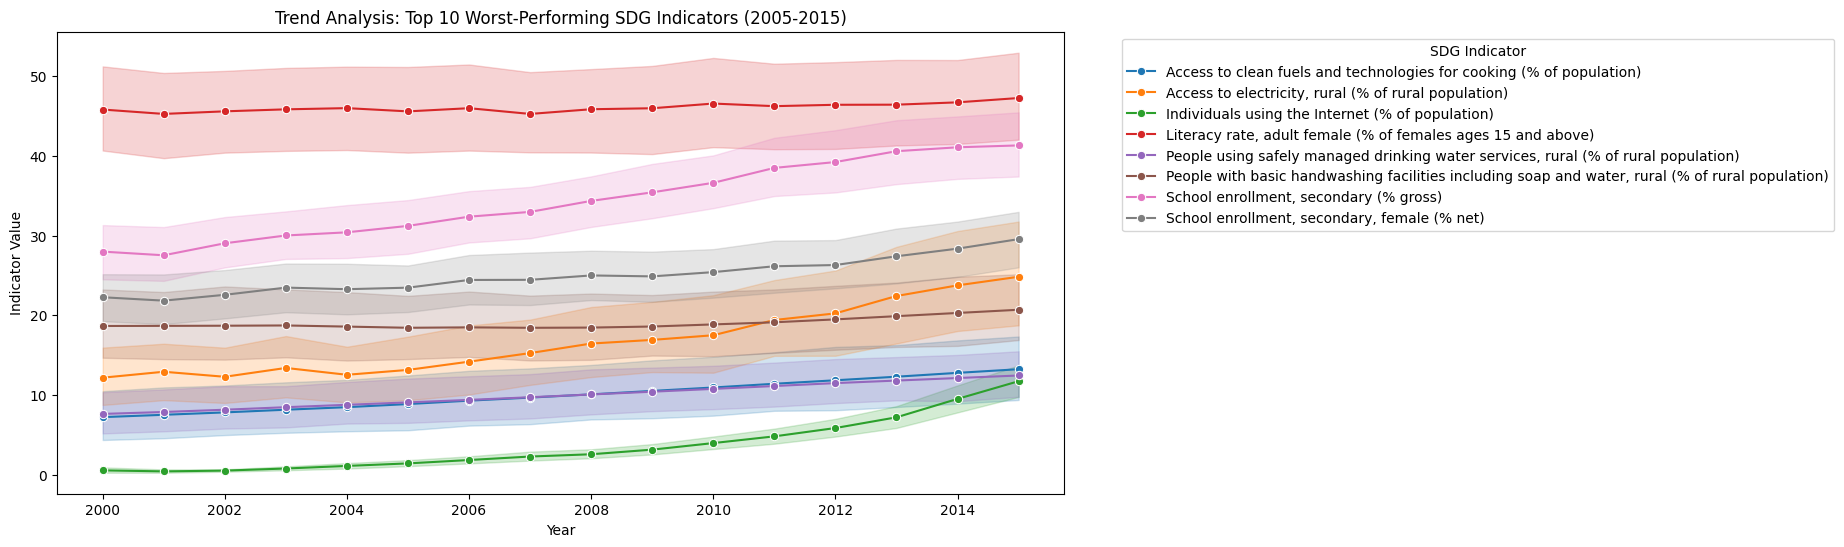

In [35]:
plt.figure(figsize=(13, 6))
sns.lineplot(data=df_trend, x="Year", y="Value",hue="Indicator",marker="o")

plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title("Trend Analysis: Top 10 Worst-Performing SDG Indicators (2005-2015)")
plt.legend(title="SDG Indicator", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### from the above graph we can say that there have less significant improvement in 15 years for the key indicators in the worst cluster


# Strategies to improve the above indicator could be 
### 1. Access to Clean Fuels and Technologies for Cooking (%)
##### Solutions:
- Subsidize LPG and electric stove and improve distribution of energy resource in rural areas

### 2. Access to Electricity (% Total & Rural)
##### Solutions:
- Encourage investment in rural electrification and deploy decentralized renewable energy solutions

### 3. People Using Safely Managed Drinking Water Services (%)
##### Solutions:
- Use Rain Water Harvesting system and provide community water filtration units

### 4.People with Basic Handwashing Facilities (% Rural)
##### Solutions:
- Use Handwashing awareness campaign and provide affordable hygiene kits

### 5.School Enrollment & Literacy Rates
##### Solutions:
- Provide free meal and sanitations to school and scholarships to improve female literacy rates

### 6.Internet Access (% of Population)
##### Solutions:
- Expand public Wi-Fi and provide affordable data plans

#### Finding the change in worst indicators in the worst performing cluster

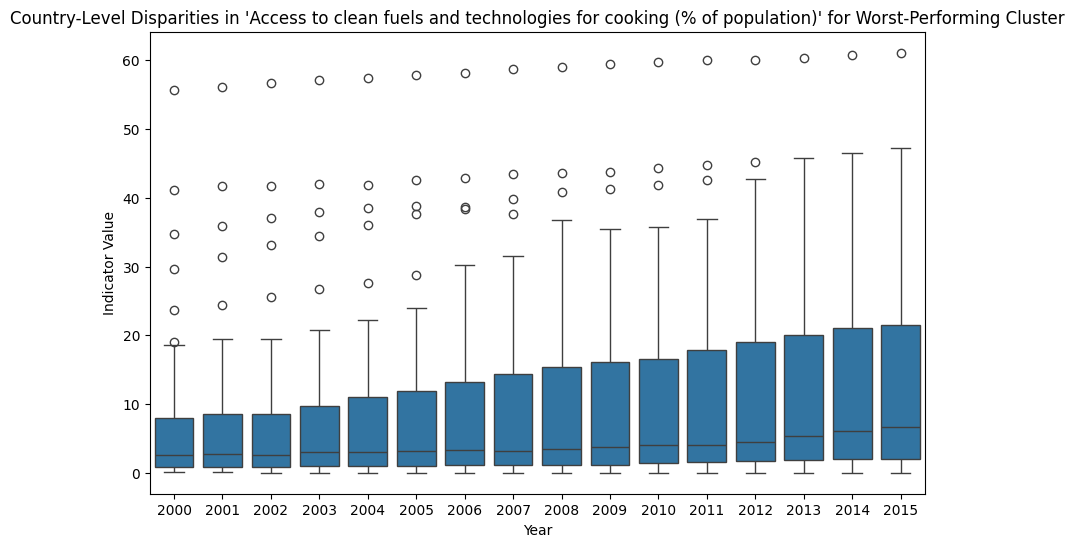

In [36]:
indicator = "Access to clean fuels and technologies for cooking (% of population)"

# Filter for the worst cluster and selected indicator
df_box=df_long[(df_long["Cluster"]==0) & (df_long["Indicator"]==indicator)]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Value", data=df_box)
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title(f"Country-Level Disparities in '{indicator}' for Worst-Performing Cluster")
plt.show()

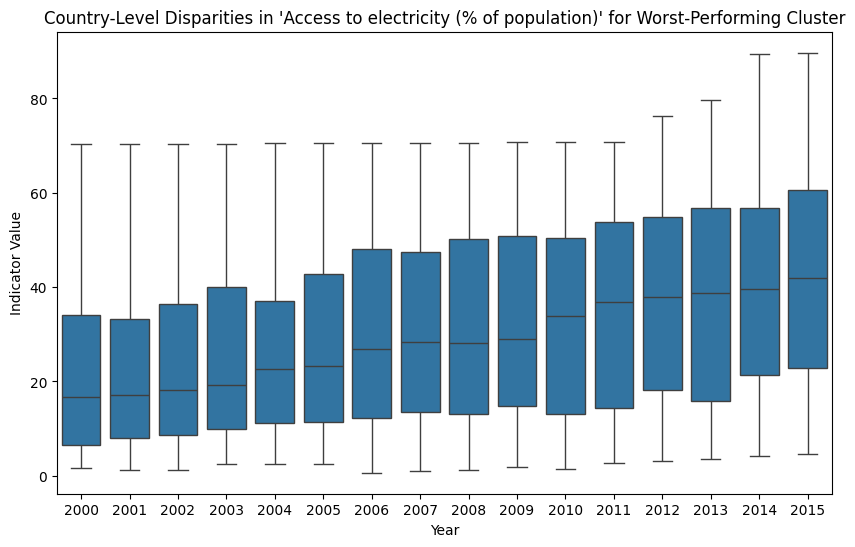

In [37]:
indicator = "Access to electricity (% of population)"

# Filter for the worst cluster and selected indicator
df_box=df_long[(df_long["Cluster"]==0) & (df_long["Indicator"]==indicator)]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Value", data=df_box)
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title(f"Country-Level Disparities in '{indicator}' for Worst-Performing Cluster")
plt.show()

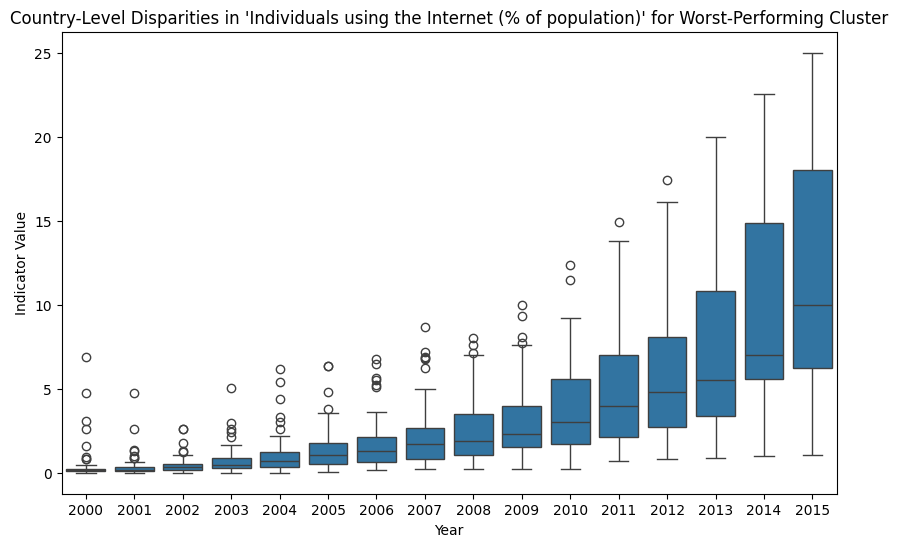

In [38]:
indicator = "Individuals using the Internet (% of population)"

# Filter for the worst cluster and selected indicator
df_box=df_long[(df_long["Cluster"]==0) & (df_long["Indicator"]==indicator)]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Value", data=df_box)
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title(f"Country-Level Disparities in '{indicator}' for Worst-Performing Cluster")
plt.show()

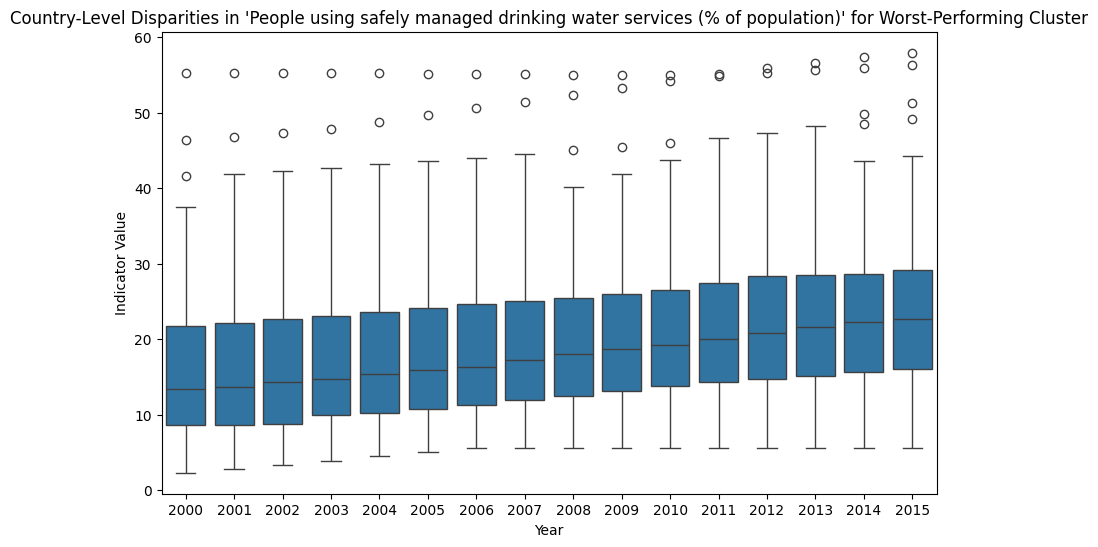

In [39]:
indicator = "People using safely managed drinking water services (% of population)"

# Filter for the worst cluster and selected indicator
df_box=df_long[(df_long["Cluster"]==0) & (df_long["Indicator"]==indicator)]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Value", data=df_box)
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title(f"Country-Level Disparities in '{indicator}' for Worst-Performing Cluster")
plt.show()

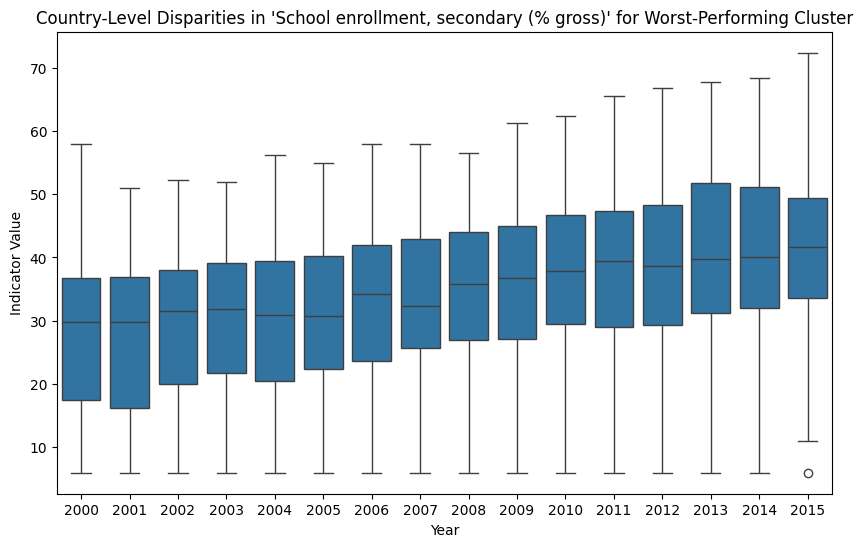

In [40]:
indicator = "School enrollment, secondary (% gross)"

# Filter for the worst cluster and selected indicator
df_box=df_long[(df_long["Cluster"]==0) & (df_long["Indicator"]==indicator)]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Value", data=df_box)
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title(f"Country-Level Disparities in '{indicator}' for Worst-Performing Cluster")
plt.show()

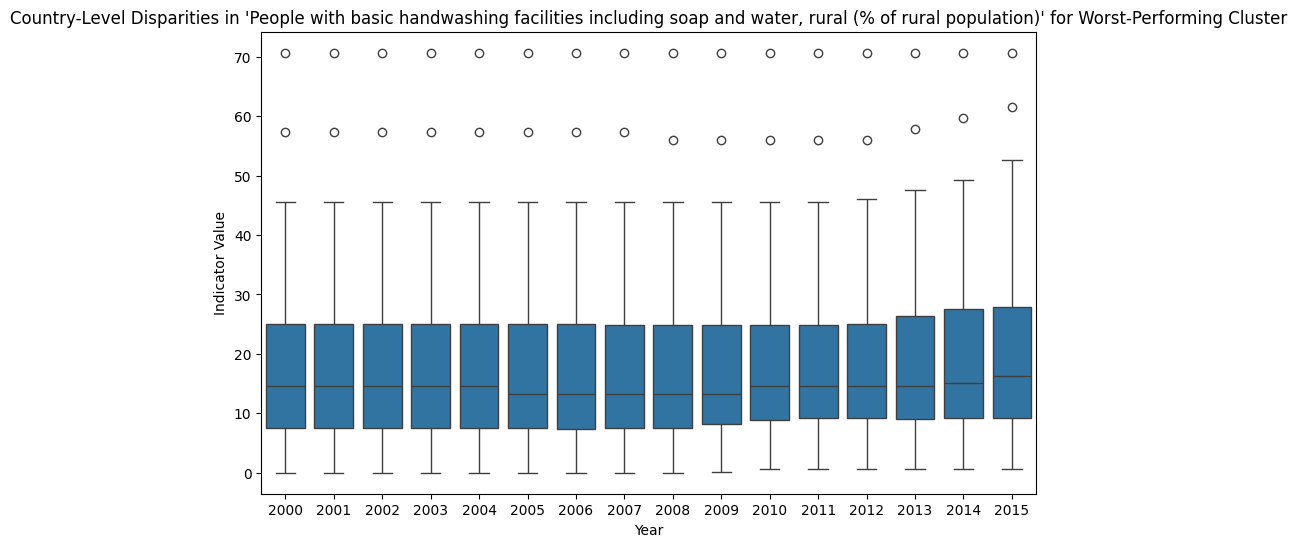

In [41]:
indicator = "People with basic handwashing facilities including soap and water, rural (% of rural population)"

# Filter for the worst cluster and selected indicator
df_box=df_long[(df_long["Cluster"]==0) & (df_long["Indicator"]==indicator)]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Value", data=df_box)
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.title(f"Country-Level Disparities in '{indicator}' for Worst-Performing Cluster")
plt.show()

##### Seperating indicators as columns to find correlation between them

In [42]:
df_corr=df_long.pivot_table(index=["country", "Cluster", "Year"],columns="Indicator",values="Value").reset_index()
df_corr


Indicator,country,Cluster,Year,Access to clean fuels and technologies for cooking (% of population),Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Adjusted savings: natural resources depletion (% of GNI),Adjusted savings: net forest depletion (% of GNI),Adolescents out of school (% of lower secondary school age),...,Time required to get electricity (days),"Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)","Trained teachers in lower secondary education, male (% of male teachers)","Trained teachers in secondary education, male (% of male teachers)","Unemployment, female (% of female labor force) (modeled ILO estimate)","Unemployment, total (% of total labor force) (modeled ILO estimate)",Unmet need for contraception (% of married women ages 15-49),Urban population (% of total population),Vitamin A supplementation coverage rate (% of children ages 6-59 months),Women Business and the Law Index Score (scale 1-100)
0,Afghanistan,0,2000,6.2,1.613591,37.263448,72.133469,0.325267,0.235844,51.399895,...,89.771429,0.21,73.485892,76.637509,13.846,10.806,24.500000,22.078,58.0,26.250
1,Afghanistan,0,2001,7.2,4.074574,37.263448,73.599037,0.325267,0.235844,55.195339,...,89.771429,0.21,73.251488,76.637509,13.849,10.809,24.500000,22.169,76.0,26.250
2,Afghanistan,0,2002,8.2,9.409158,37.263448,75.063278,0.325267,0.235844,54.190393,...,89.771429,0.21,73.269968,76.637509,14.355,11.257,24.500000,22.261,94.0,26.250
3,Afghanistan,0,2003,9.5,14.738506,37.263448,76.533134,0.325267,0.235844,51.399895,...,89.771429,0.21,67.504758,76.637509,14.222,11.141,24.500000,22.353,71.0,26.250
4,Afghanistan,0,2004,10.9,20.064968,3.240604,78.015556,0.325267,0.235844,55.764351,...,89.771429,0.21,73.903626,77.546346,14.047,10.988,24.500000,22.500,95.0,26.250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3467,Zimbabwe,3,2011,30.1,36.900002,14.080046,83.199997,6.010050,3.152398,8.675770,...,125.000000,3.52,71.870331,71.526505,5.988,5.370,14.600000,33.015,47.0,86.875
3468,Zimbabwe,3,2012,29.8,44.000000,23.746748,85.430527,4.840999,3.025565,4.727400,...,106.000000,3.52,71.905744,67.818031,5.695,5.153,12.720532,32.834,61.0,86.875
3469,Zimbabwe,3,2013,29.8,40.498375,18.698282,85.459152,4.212639,2.829242,2.254170,...,106.000000,3.52,71.910552,71.161583,5.451,4.982,12.720532,32.654,34.0,86.875
3470,Zimbabwe,3,2014,29.5,32.299999,7.691812,83.400002,4.596318,3.146764,2.626320,...,106.000000,3.52,71.868968,72.651047,5.166,4.770,10.382129,32.504,32.0,86.875


### Finding correlation between poverty,education and healthcare between different clusters

In [43]:
correlated_indicators=["Births attended by skilled health staff (% of total)","Community health workers (per 1,000 people)","Hospital beds (per 1,000 people)",
                       "School enrollment, secondary (% gross)","School enrollment, tertiary (% gross)","Government expenditure on education, total (% of government expenditure)",
                       "Multidimensional poverty index (scale 0-1)","Multidimensional poverty headcount ratio (% of total population)","Poverty headcount ratio at national poverty lines (% of population)"]

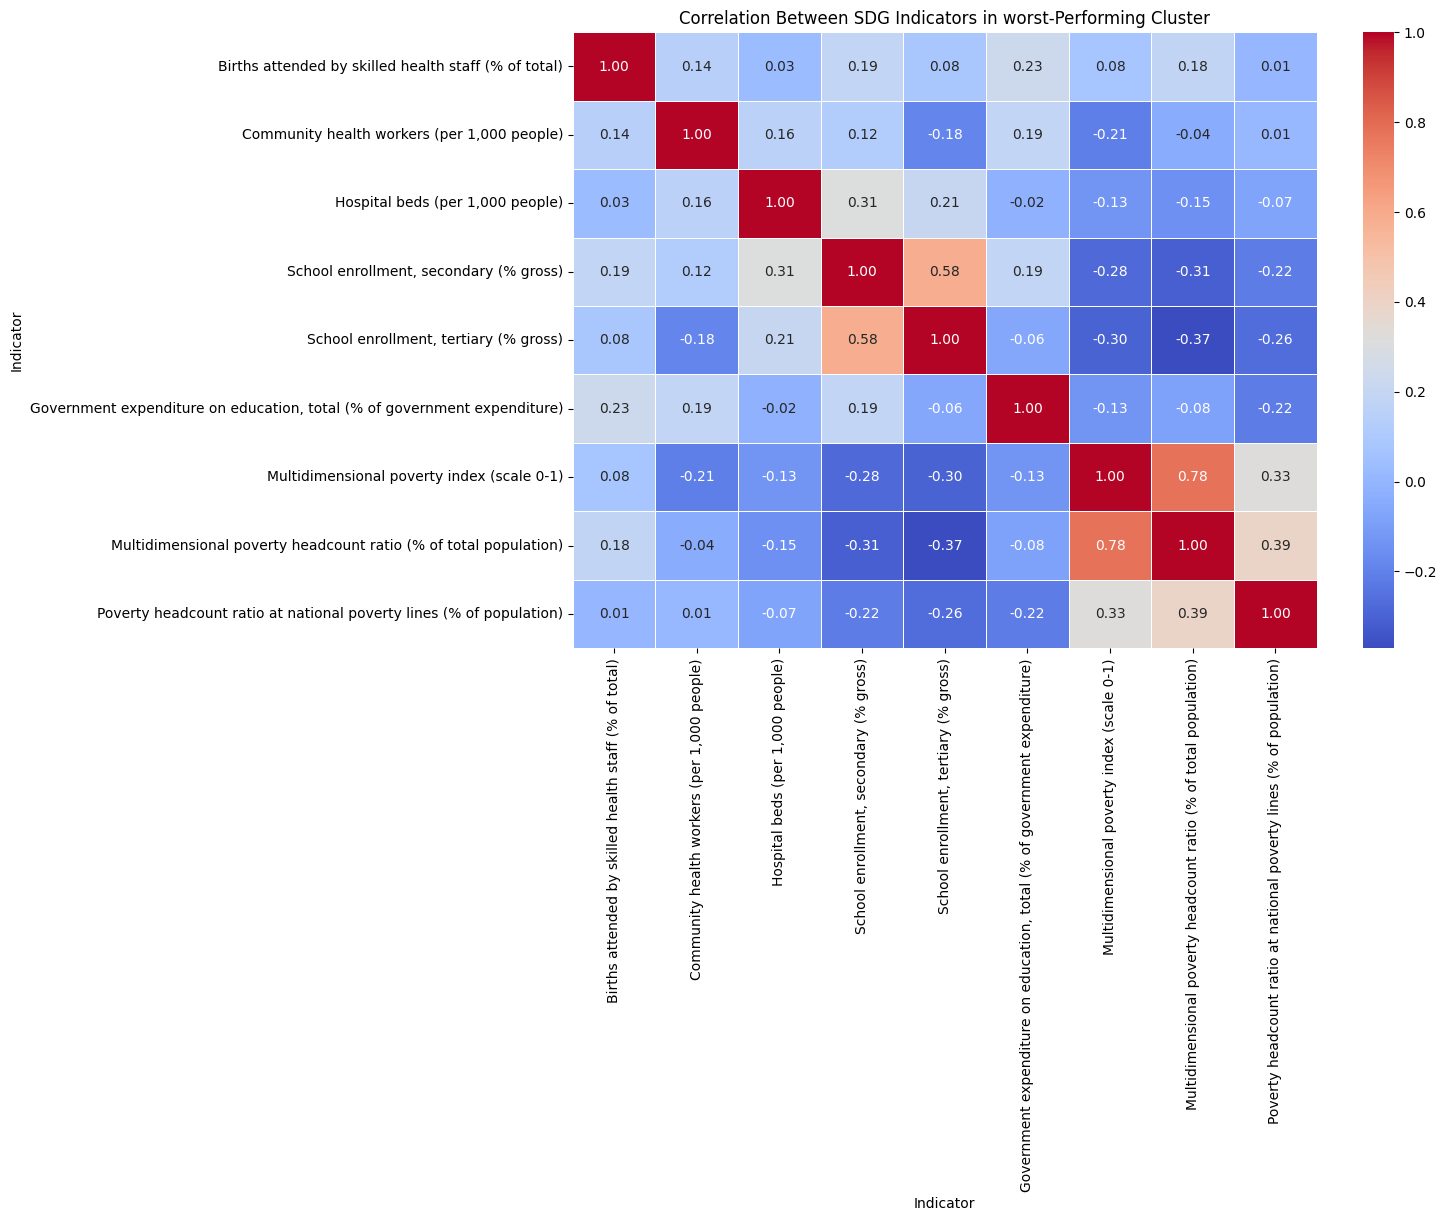

In [44]:
df_corr_0=df_corr[df_corr["Cluster"]==0].drop(columns=["country","Cluster","Year"])
corr_matrix_0=df_corr_0[correlated_indicators].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_0, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Between SDG Indicators in worst-Performing Cluster")
plt.show()

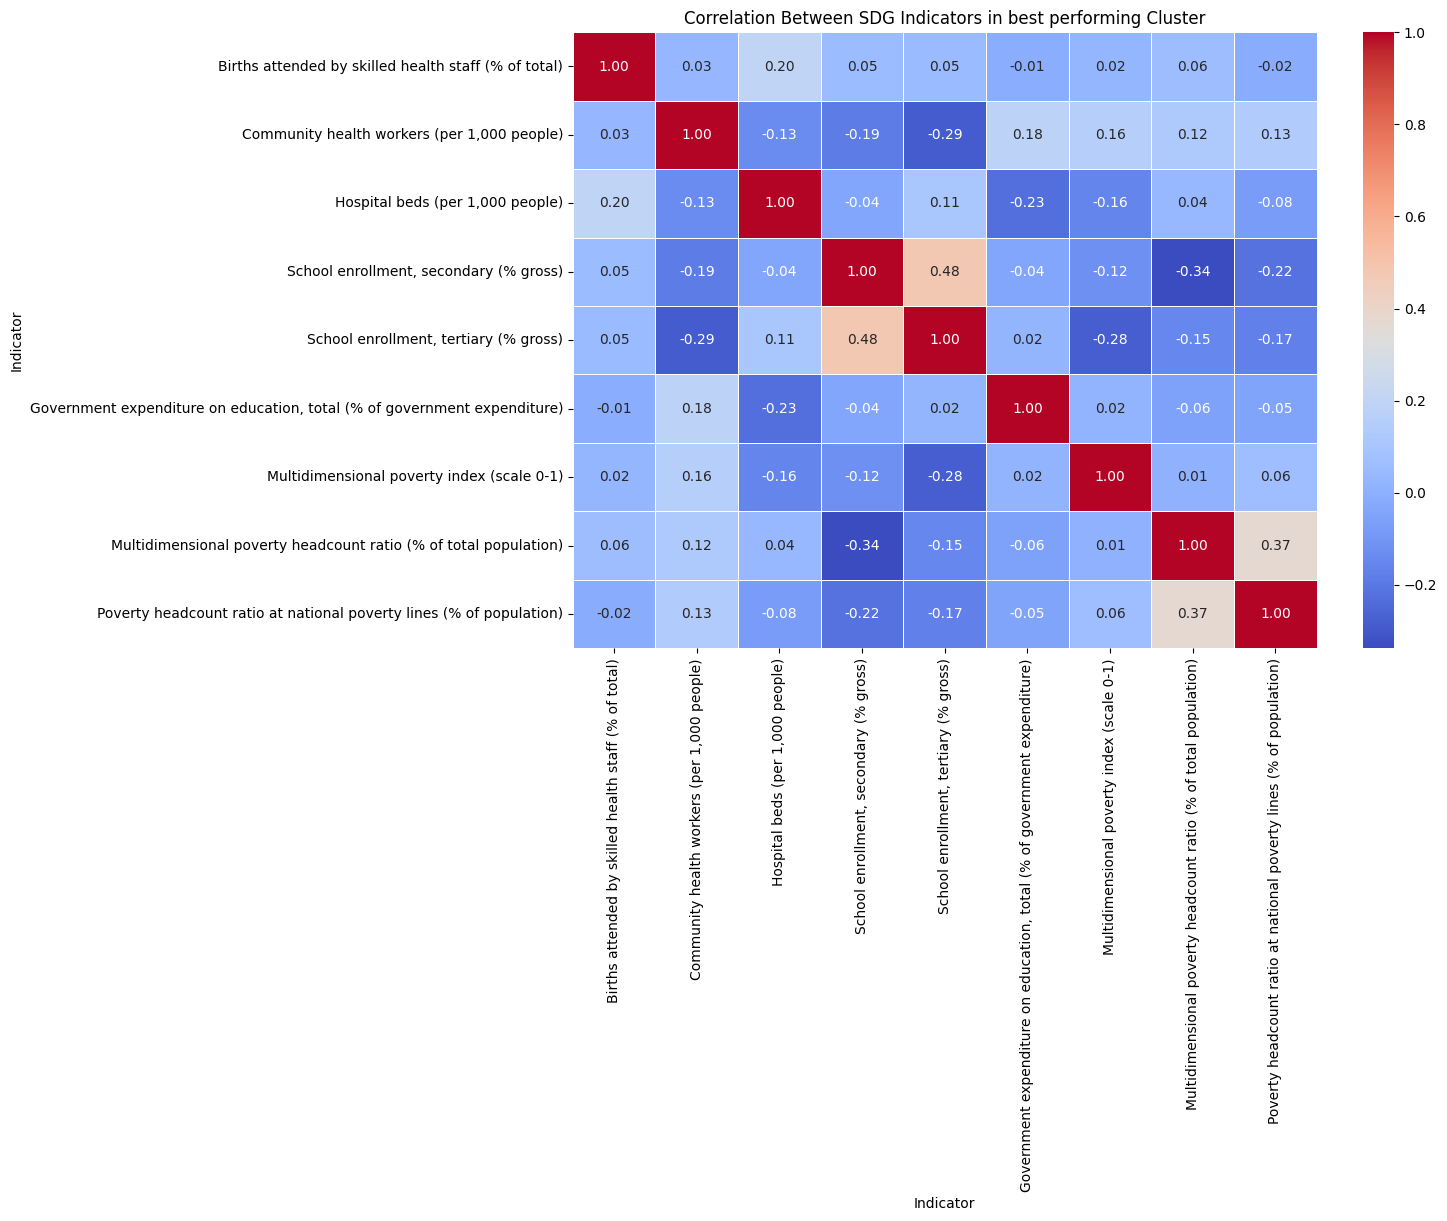

In [45]:
df_corr_1=df_corr[df_corr["Cluster"]==1].drop(columns=["country","Cluster","Year"])
corr_matrix_1=df_corr_1[correlated_indicators].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_1, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Between SDG Indicators in best performing Cluster")
plt.show()

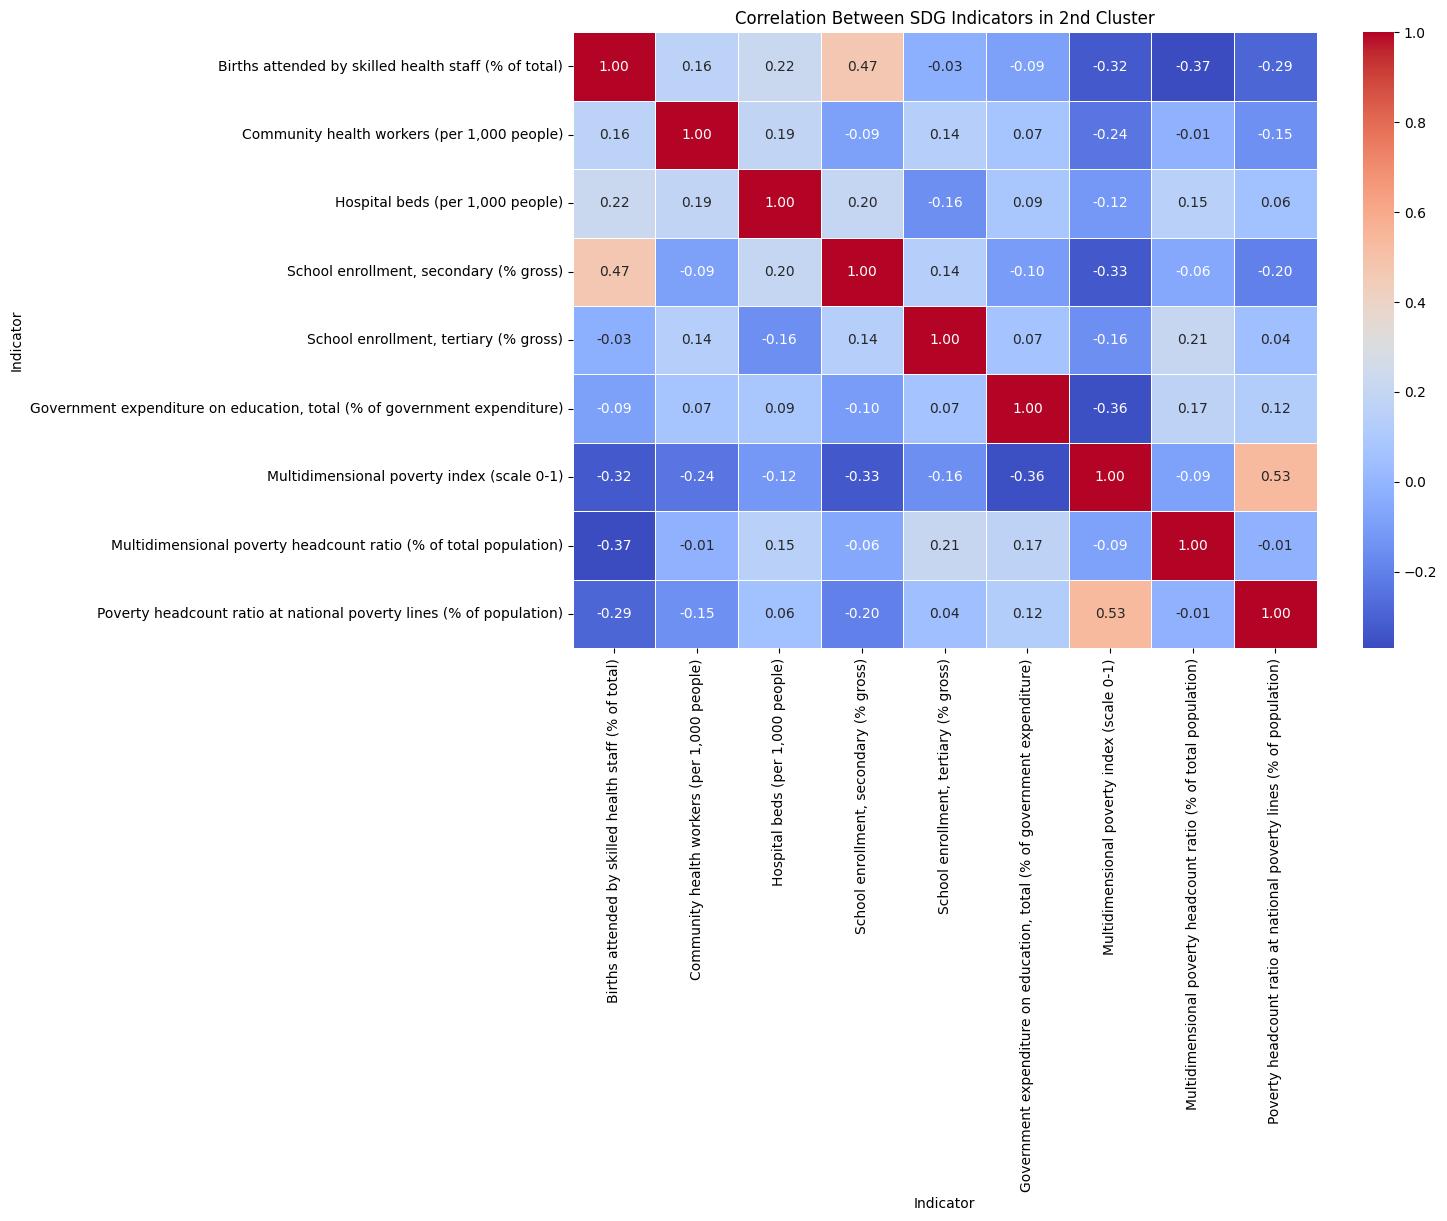

In [46]:
df_corr_2=df_corr[df_corr["Cluster"]==2].drop(columns=["country","Cluster","Year"])
corr_matrix_2=df_corr_2[correlated_indicators].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_2, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Between SDG Indicators in 2nd Cluster")
plt.show()

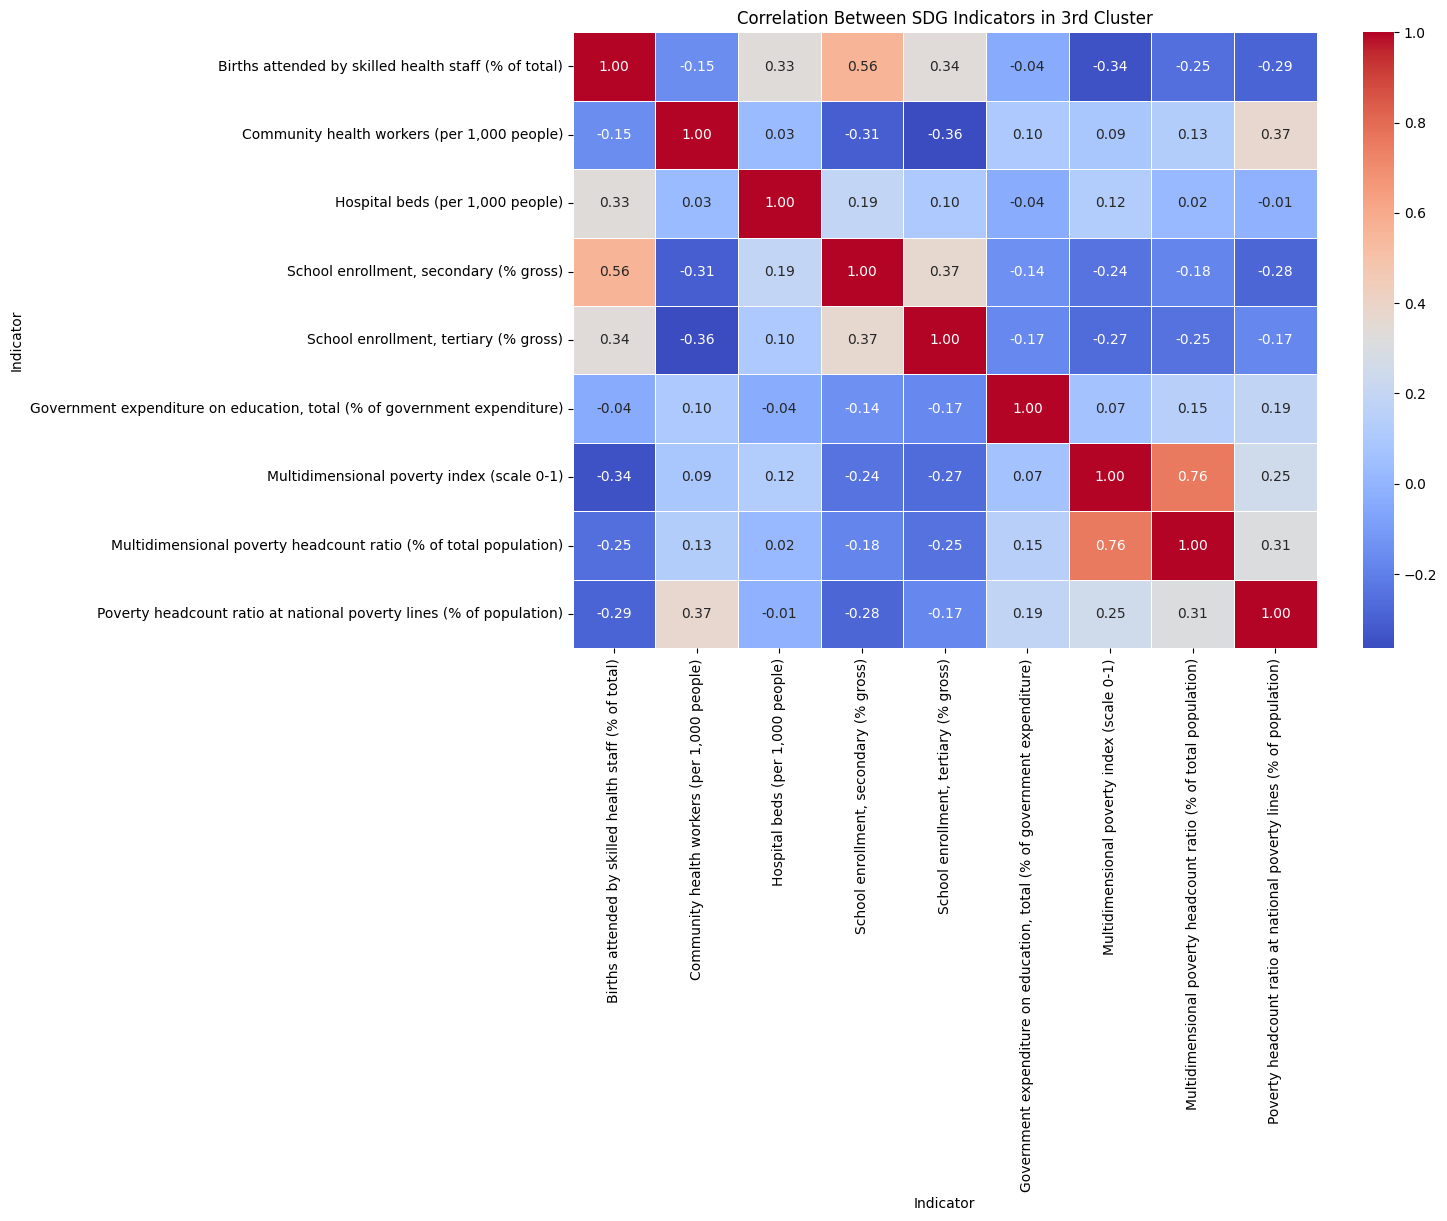

In [47]:
df_corr_3=df_corr[df_corr["Cluster"]==3].drop(columns=["country","Cluster","Year"])
corr_matrix_3=df_corr_3[correlated_indicators].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_3, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Between SDG Indicators in 3rd Cluster")
plt.show()

The above graphs shows that: 
- For an increase in multidimensional poverty  there is a reduction in the  school enrollment 
- Increase in goverment expenditure on education reducs the poverty headcount which menas less people live below poverty line
- More hospital beds increase the school enrollment no 
- More hospital beds reduces the poverty in the countries


## Creating a model to predict following targets by 2030
- 50% of total energy requirements met through renewable sources.
- 45% reduction in carbon intensity from 2005 levels.

In [48]:
df_india_2 = df_long.loc[(df_long["Indicator"] == "Renewable energy consumption (% of total final energy consumption)") & (df_long["country"]=="India")]
df_india_2

,country,Cluster,Value,Year,Indicator
20704,India,3,46.88,2000,Renewable energy consumption (% of total final...
46310,India,3,47.11,2001,Renewable energy consumption (% of total final...
71916,India,3,45.75,2002,Renewable energy consumption (% of total final...
97522,India,3,45.63,2003,Renewable energy consumption (% of total final...
123128,India,3,44.92,2004,Renewable energy consumption (% of total final...
148734,India,3,44.16,2005,Renewable energy consumption (% of total final...
174340,India,3,43.16,2006,Renewable energy consumption (% of total final...
199946,India,3,41.53,2007,Renewable energy consumption (% of total final...
225552,India,3,39.37,2008,Renewable energy consumption (% of total final...
251158,India,3,37.41,2009,Renewable energy consumption (% of total final...


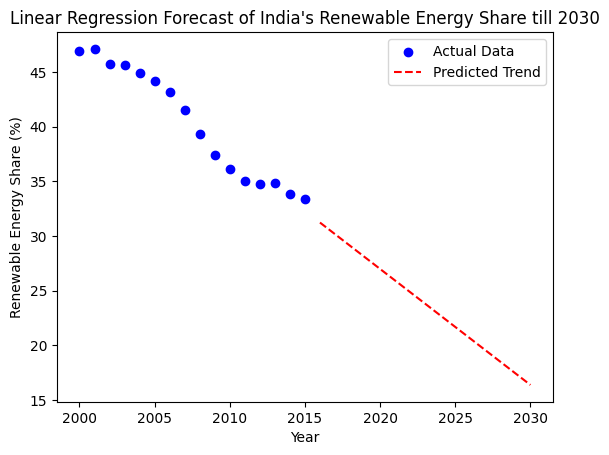

Predicted Renewable Energy Share for 2030: 16.38%


In [49]:
# Prepare features and target variable
X=df_india_2["Year"].values.reshape(-1, 1)  # Independent variable (Year)
y=df_india_2["Value"].values  # Dependent variable

# Train the Linear Regression model
model=LinearRegression()
model.fit(X, y)

# Predict for future years (2016-2030)
future_years=np.array(range(2016, 2031)).reshape(-1, 1)
future_predictions=model.predict(future_years)

# Plot historical data and predictions
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(future_years, future_predictions, color="red", linestyle="dashed", label="Predicted Trend")
plt.xlabel("Year")
plt.ylabel("Renewable Energy Share (%)")
plt.title("Linear Regression Forecast of India's Renewable Energy Share till 2030")
plt.legend()
plt.show()

# Print predicted value for 2030
pred_2030 = model.predict([[2030]])[0]
print(f"Predicted Renewable Energy Share for 2030: {pred_2030:.2f}%")

- from the graph above from 2000-2015 we can say that if India does not increase its"Renewable Energy Source" it will not reach the desired goal of 2030

In [50]:
df_india_3=df_long.loc[(df_long["Indicator"]=="CO2 emissions (metric tons per capita)") & (df_long["country"]=="India") & (df_long["Year"].isin(range(2005,2016)))]
df_india_3

,country,Cluster,Value,Year,Indicator
131808,India,3,0.984265,2005,CO2 emissions (metric tons per capita)
157414,India,3,1.036538,2006,CO2 emissions (metric tons per capita)
183020,India,3,1.123602,2007,CO2 emissions (metric tons per capita)
208626,India,3,1.180359,2008,CO2 emissions (metric tons per capita)
234232,India,3,1.278873,2009,CO2 emissions (metric tons per capita)
259838,India,3,1.338031,2010,CO2 emissions (metric tons per capita)
285444,India,3,1.396875,2011,CO2 emissions (metric tons per capita)
311050,India,3,1.498203,2012,CO2 emissions (metric tons per capita)
336656,India,3,1.527675,2013,CO2 emissions (metric tons per capita)
362262,India,3,1.642468,2014,CO2 emissions (metric tons per capita)


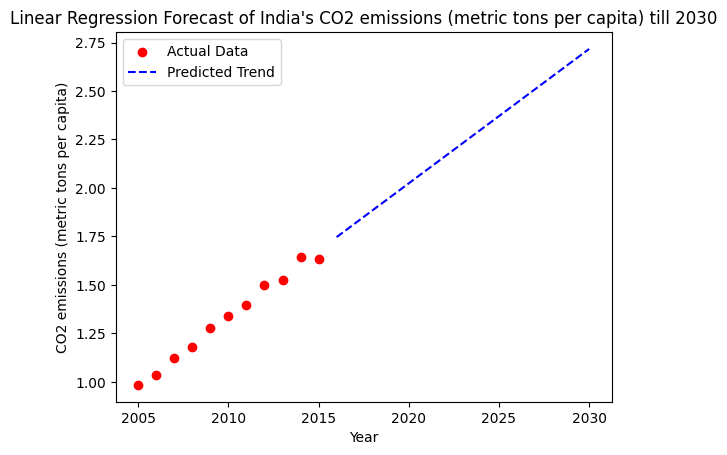

Predicted CO2 emissions (metric tons per capita) for 2030: 2.72
Predicted percent change in CO2 emission from 2005 to 2030 is: 176.05%


In [51]:
# Prepare features and target variable
X_1=df_india_3["Year"].values.reshape(-1, 1)  
y_1=df_india_3["Value"].values  


model=LinearRegression()
model.fit(X_1, y_1)

future_years1=np.array(range(2016, 2031)).reshape(-1, 1)
future_predictions1=model.predict(future_years)

# Plot historical data and predictions
plt.scatter(X_1, y_1, color="red", label="Actual Data")
plt.plot(future_years1, future_predictions1, color="blue", linestyle="dashed", label="Predicted Trend")
plt.xlabel("Year")
plt.ylabel("CO2 emissions (metric tons per capita)")
plt.title("Linear Regression Forecast of India's CO2 emissions (metric tons per capita) till 2030")
plt.legend()
plt.show()

# Print predicted value for 2030
pred_2030 = model.predict([[2030]])[0]
print(f"Predicted CO2 emissions (metric tons per capita) for 2030: {pred_2030:.2f}")
percent_change=(pred_2030-y_1[0])/y_1[0]*100
print(f"Predicted percent change in CO2 emission from 2005 to 2030 is: {percent_change:.2f}%")

from the above graph CO2 emissions will increase upto 176% of 2005 if no proper policy change is implemented